<a href="https://colab.research.google.com/github/abhaychandeltech-web/Actuall-Price-Predcetion/blob/main/Copy_of_Untitled9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import userdata

API_KEY = userdata.get('KAGGLE_KEY')

In [ ]:
import os
from google.colab import userdata
userdata.get('Secret Key')


In [ ]:

!kaggle datasets download -d camnugent/california-housing-prices --unzip

Dataset URL: https://www.kaggle.com/datasets/camnugent/california-housing-prices
License(s): CC0-1.0
100% 400k/400k [00:00<00:00, 101MB/s]



In [ ]:
import pandas as pd
california = pd.read_csv('/root/<xxxx>housing.csv')

X = california.drop('median_house_value', axis=1)
y = california['median_house_value']
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY


In [ ]:
print('Missing values in X:')
display(X.isnull().sum())
for col in X.columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())
print('\nMissing values in X after imputation:')
display(X.isnull().sum())
# Check for missing values in y
print('\nMissing values in y:')
display(y.isnull().sum())

Missing values in X:


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
ocean_proximity,0



Missing values in X after imputation:


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
ocean_proximity,0



Missing values in y:


np.int64(0)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16512, 9)
X_test shape: (4128, 9)
y_train shape: (16512,)
y_test shape: (4128,)


In [ ]:
california['total_bedrooms'] = california['total_bedrooms'].fillna(california['total_bedrooms'].median())
california_encoded = pd.get_dummies(california, columns=['ocean_proximity'])
X_encoded = california_encoded.drop('median_house_value', axis=1)
y_encoded = california_encoded['median_house_value']
X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42)
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train_enc, y_train_enc)

RandomForestRegressor(n_estimators=50, random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
predictions = model.predict(X_test_enc)
mae = mean_absolute_error(y_test_enc, predictions)
print(f"Mean Absolute Error: {mae:.2f}")
mse = mean_squared_error(y_test_enc, predictions)
print(f"Mean Squared Error: {mse:.2f}")
r2= r2_score(y_test_enc,predictions)
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 31908.96
Mean Squared Error: 2392182832.85
R2 Score: 0.82


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming metrics_df is already defined from previous steps
# If not, you would create it like this:
# metrics_data = {
#     'Metric': ['R2 Score', 'Mean Absolute Error', 'Mean Squared Error'],
#     'Value': [r2, mae, mse]
# }
# metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', data=metrics_df, palette='viridis')
plt.title('Random Forest Regressor Performance Metrics')
plt.ylabel('Value')
plt.xlabel('Metric')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

NameError: name 'metrics_df' is not defined

<Figure size 1000x600 with 0 Axes>

/tmp/ipykernel_3171/4183897839.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=metrics_df, palette='viridis')


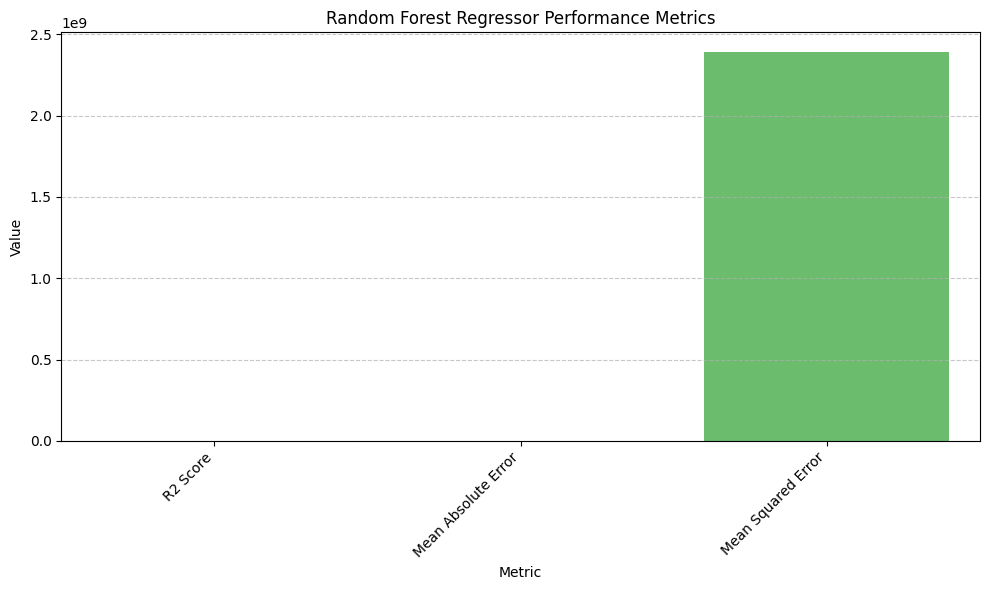

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics_data = {
    'Metric': ['R2 Score', 'Mean Absolute Error', 'Mean Squared Error'],
    'Value': [r2, mae, mse]
}
metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', data=metrics_df, palette='viridis')
plt.title('Random Forest Regressor Performance Metrics')
plt.ylabel('Value')
plt.xlabel('Metric')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

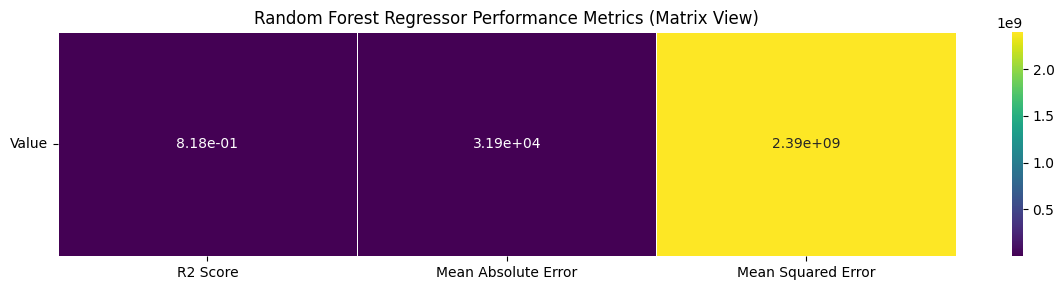

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure metrics_df is correctly defined from the calculated values
# These values (r2, mae, mse) are available from previous cell execution
metrics_data = {
    'Metric': ['R2 Score', 'Mean Absolute Error', 'Mean Squared Error'],
    'Value': [r2, mae, mse]
}
metrics_df = pd.DataFrame(metrics_data)

# Reshape the DataFrame to a single row for a 1xN heatmap representation
heatmap_data = metrics_df.set_index('Metric').T

plt.figure(figsize=(12, 3)) # Adjust figure size for better display of a single row
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt='.2e', linewidths=.5, cbar=True)
plt.title('Random Forest Regressor Performance Metrics (Matrix View)')
plt.yticks(rotation=0) # Keep y-axis labels horizontal
plt.xlabel('') # Remove x-label as metric names are on the heatmap
plt.ylabel('') # Remove y-label
plt.tight_layout()
plt.show()

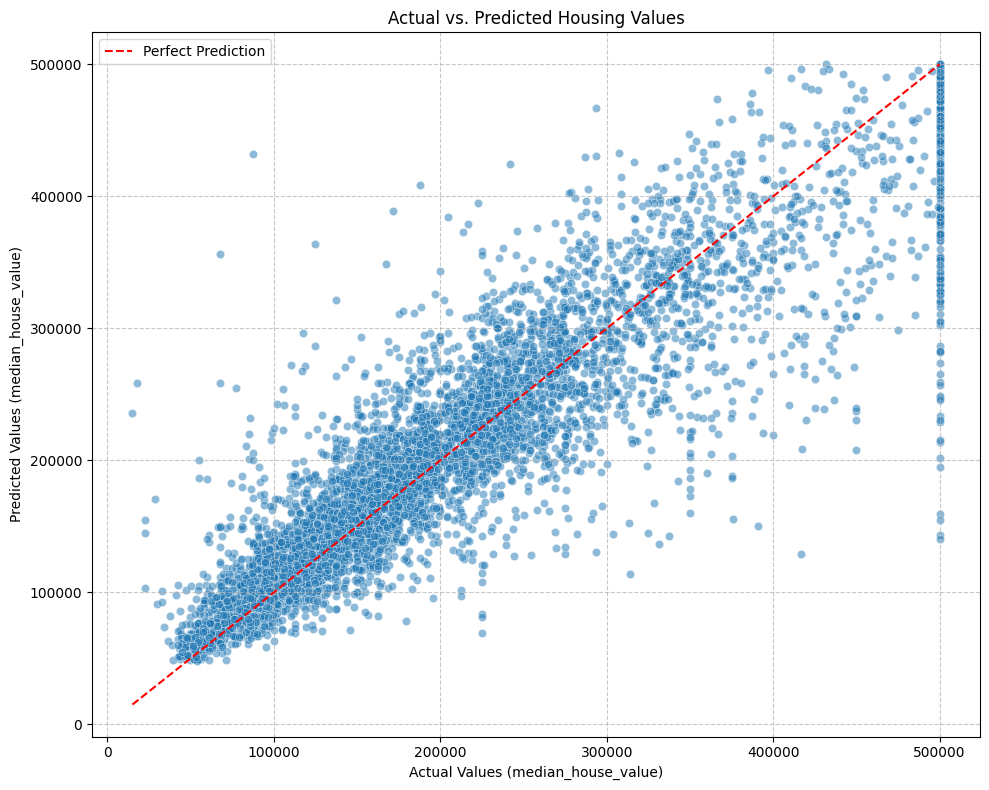

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming y_test_enc and predictions are available from previous cell execution

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test_enc, y=predictions, alpha=0.5)

# Add a diagonal line for perfect predictions
min_val = min(y_test_enc.min(), predictions.min())
max_val = max(y_test_enc.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Actual vs. Predicted Housing Values')
plt.xlabel('Actual Values (median_house_value)')
plt.ylabel('Predicted Values (median_house_value)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()